# Experiment Tracking — TensorBoard + wandb (hands-on)

One training loop on `sklearn` digits, logged to **both** trackers, then **read back inline** so the
notebook shows what was recorded without launching any server:

1. **TensorBoard** via `SummaryWriter` — scalars, histogram, image, hparams. We parse the event
   files back with `tbparse` and plot them here.
2. **wandb** in **offline mode** (no account / no network) — `wandb.log(...)`, then inspect the
   local run directory and its logged history.

Companion to [experiment_tracking.md](experiment_tracking.md). CPU only.


In [1]:
import os, glob
os.environ["WANDB_MODE"] = "offline"      # log locally, no account/network
os.environ["WANDB_SILENT"] = "true"

import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from torch.utils.tensorboard import SummaryWriter
import wandb

torch.manual_seed(0); np.random.seed(0)
LOGROOT = "/tmp/tracking_demo"
os.makedirs(LOGROOT, exist_ok=True)
print("torch", torch.__version__, "| wandb", wandb.__version__)


torch 2.12.0+cu130 | wandb 0.27.2


## 1. Data + model

In [2]:
d = load_digits()
X = (d.data.astype(np.float32) / 16.0); y = d.target.astype(np.int64)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
Xtr_t, ytr_t = torch.tensor(Xtr), torch.tensor(ytr)
Xte_t, yte_t = torch.tensor(Xte), torch.tensor(yte)
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Xtr_t, ytr_t), batch_size=64, shuffle=True)

class MLP(nn.Module):
    def __init__(self, h=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(64, h), nn.ReLU(), nn.Linear(h, 10))
        self.h = h
    def forward(self, x): return self.net(x)

@torch.no_grad()
def val_acc(m):
    m.eval(); return (m(Xte_t).argmax(1) == yte_t).float().mean().item()

config = {"lr": 0.05, "batch_size": 64, "hidden": 128, "epochs": 15, "optimizer": "adam"}
print("train", len(Xtr), "test", len(Xte), "| config", config)


train 1257 test 540 | config {'lr': 0.05, 'batch_size': 64, 'hidden': 128, 'epochs': 15, 'optimizer': 'adam'}


## 2. Train once, log to BOTH trackers

We open a TensorBoard `SummaryWriter` and a wandb run (offline), then in the loop call
`writer.add_scalar(...)` and `wandb.log(...)` with the **same global step**.


In [3]:
run_dir = os.path.join(LOGROOT, "runs", "mlp_lr0.05")
writer = SummaryWriter(log_dir=run_dir)                              # TensorBoard
wb = wandb.init(project="digits-demo", name="mlp_lr0.05",
                config=config, dir=LOGROOT, mode="offline")          # wandb (offline)

torch.manual_seed(1)
model = MLP(config["hidden"])
opt = torch.optim.Adam(model.parameters(), lr=config["lr"])

step = 0
for epoch in range(config["epochs"]):
    model.train()
    for xb, yb in train_loader:
        opt.zero_grad()
        loss = F.cross_entropy(model(xb), yb)
        loss.backward(); opt.step()
        # ---- scalars to both ----
        writer.add_scalar("train/loss", loss.item(), step)
        wandb.log({"train/loss": loss.item()}, step=step)
        step += 1
    acc = val_acc(model)
    writer.add_scalar("val/acc", acc, step)
    wandb.log({"val/acc": acc, "epoch": epoch}, step=step)
    # ---- a weight histogram (TensorBoard) ----
    writer.add_histogram("weights/fc1", model.net[0].weight, step)

final_acc = val_acc(model)

# ---- a media item: confusion matrix, to BOTH ----
with torch.no_grad():
    pred = model(Xte_t).argmax(1).numpy()
cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm, cmap="Blues"); ax.set_title(f"Confusion (acc={final_acc:.3f})")
ax.set_xlabel("pred"); ax.set_ylabel("true"); fig.colorbar(im, fraction=0.046)
writer.add_figure("eval/confusion_matrix", fig, step)
wandb.log({"eval/confusion_matrix": wandb.Image(fig)})

# ---- hyperparameters table ----
writer.add_hparams(config, {"hparam/val_acc": final_acc})

writer.close()                 # flush TensorBoard events
wb.finish()                    # finalize the wandb run
plt.close(fig)
print(f"done. final val acc = {final_acc:.4f}")
print("TensorBoard run dir:", run_dir)
print("wandb run dir:", wb.dir)


done. final val acc = 0.9667
TensorBoard run dir: /tmp/tracking_demo/runs/mlp_lr0.05
wandb run dir: /tmp/tracking_demo/wandb/offline-run-20260614_110712-21ld9yrs/files


## 3. Read the TensorBoard logs back (inline)

We parse the event files with `tbparse` into a DataFrame and re-plot — exactly the curves the
TensorBoard UI would show, but rendered in the notebook so they persist in the committed output.


logged scalar tags: ['hparam/val_acc', 'train/loss', 'val/acc']


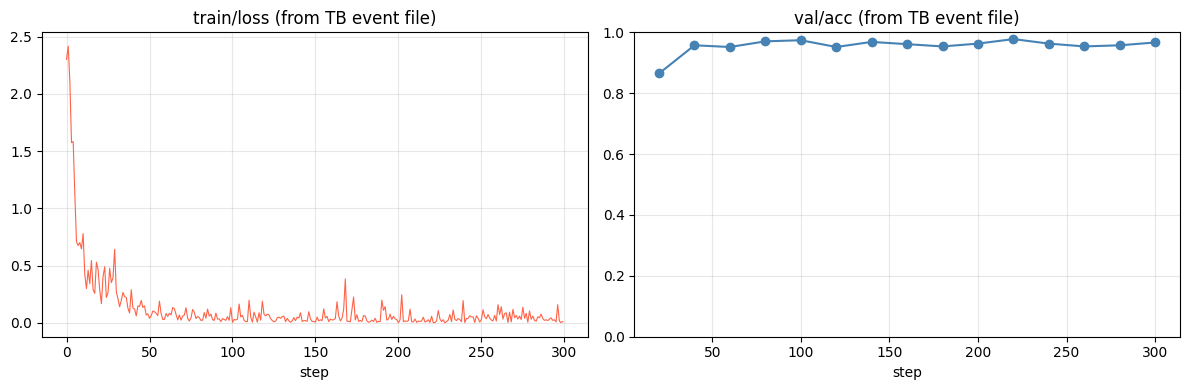

scalar rows parsed: 316


In [4]:
from tbparse import SummaryReader

reader = SummaryReader(run_dir)
scalars = reader.scalars                      # tidy DataFrame: columns [step, tag, value]
print("logged scalar tags:", sorted(scalars["tag"].unique()))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
loss = scalars[scalars.tag == "train/loss"]
ax[0].plot(loss.step, loss.value, color="tomato", lw=0.8)
ax[0].set_title("train/loss (from TB event file)"); ax[0].set_xlabel("step"); ax[0].grid(alpha=0.3)
acc = scalars[scalars.tag == "val/acc"]
ax[1].plot(acc.step, acc.value, "o-", color="steelblue")
ax[1].set_title("val/acc (from TB event file)"); ax[1].set_xlabel("step"); ax[1].set_ylim(0,1); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# The weight histogram and confusion-matrix figure are also in the event file; they render in the
# TensorBoard web UI (`tensorboard --logdir`) under the Histograms / Images tabs. (tbparse reads
# scalars without extra deps; histogram/image parsing needs the tensorflow backend.)
print("scalar rows parsed:", len(scalars))


## 4. Inspect the wandb offline run

In offline mode wandb writes everything to a local `offline-run-*` directory. You inspect the
logged history programmatically, and later upload it with `wandb sync <dir>` from a machine with
internet.


In [5]:
# locate the offline run directory
offline_dirs = sorted(glob.glob(os.path.join(LOGROOT, "wandb", "offline-run-*")))
print("offline run dirs:", [os.path.basename(d) for d in offline_dirs])
rundir = offline_dirs[-1]
print("\ncontents:")
for f in sorted(os.listdir(rundir)):
    p = os.path.join(rundir, f)
    sz = os.path.getsize(p) if os.path.isfile(p) else 0
    print(f"  {f}  ({sz} bytes)" if os.path.isfile(p) else f"  {f}/")

# media we logged (the confusion-matrix Image) is saved under files/media:
media = glob.glob(os.path.join(rundir, "files", "media", "**", "*"), recursive=True)
print("\nlogged media files:", [os.path.basename(m) for m in media if os.path.isfile(m)])

# The run's metrics/config/history live in the binary run-*.wandb record; offline they are read
# back after `wandb sync` (which uploads) or via wandb.Api(). The local .wandb file is self-contained:
wfile = glob.glob(os.path.join(rundir, "*.wandb"))
print("offline record:", os.path.basename(wfile[0]), f"({os.path.getsize(wfile[0])} bytes)")
print("\nTo upload later:  wandb sync", rundir)


offline run dirs: ['offline-run-20260614_110712-21ld9yrs']

contents:
  files/
  logs/
  run-21ld9yrs.wandb  (97329 bytes)
  tmp/

logged media files: ['confusion_matrix_300_64010e671ef9460f857a.png']
offline record: run-21ld9yrs.wandb (97329 bytes)

To upload later:  wandb sync /tmp/tracking_demo/wandb/offline-run-20260614_110712-21ld9yrs


## 5. Reading wandb history with the public API

`wandb.Api()` reads runs back as DataFrames (works on synced runs; shown here as the pattern you'd
use after `wandb sync`). For sweeps you'd define a `sweep.yaml` and launch `wandb agent` — see
[experiment_tracking.md](experiment_tracking.md) §5.


In [6]:
# Pattern (requires the run to be synced/online):
#   api = wandb.Api()
#   run = api.run("entity/digits-demo/<run_id>")
#   history = run.history()          # -> pandas DataFrame of all logged steps
#   config  = run.config             # the hyperparameters
#   summary = run.summary            # final metrics
#
# A sweep is just a config + agents:
sweep_config = {
    "method": "bayes",
    "metric": {"name": "val/acc", "goal": "maximize"},
    "parameters": {
        "lr":         {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-1},
        "batch_size": {"values": [32, 64, 128]},
        "hidden":     {"values": [64, 128, 256]},
    },
}
print("example sweep config:")
import json; print(json.dumps(sweep_config, indent=2))
print("\n# wandb sweep sweep.yaml   ->  SWEEP_ID")
print("# wandb agent <SWEEP_ID>    (run trials; on Slurm: a job array of agents)")


example sweep config:
{
  "method": "bayes",
  "metric": {
    "name": "val/acc",
    "goal": "maximize"
  },
  "parameters": {
    "lr": {
      "distribution": "log_uniform_values",
      "min": 0.0001,
      "max": 0.1
    },
    "batch_size": {
      "values": [
        32,
        64,
        128
      ]
    },
    "hidden": {
      "values": [
        64,
        128,
        256
      ]
    }
  }
}

# wandb sweep sweep.yaml   ->  SWEEP_ID
# wandb agent <SWEEP_ID>    (run trials; on Slurm: a job array of agents)


## 6. Takeaways

- The **same loop** feeds both trackers: `writer.add_scalar(tag, val, step)` and
  `wandb.log({tag: val}, step=step)`. Keep a single global-step convention.
- **TensorBoard** = local event files; parse them with `tbparse`/`EventAccumulator` or serve with
  `tensorboard --logdir runs`. Great for fast local debugging and the PyTorch profiler.
- **wandb offline** logs to `wandb/offline-run-*` with no network; `wandb sync` uploads later — the
  standard pattern on air-gapped clusters. Online, you additionally get config search, system
  metrics, **sweeps**, and **artifact** lineage.
- Log media (confusion matrix here) and **hyperparameters** (`add_hparams` / `config`) — without the
  config you can't compare runs later.

See [experiment_tracking.md](experiment_tracking.md) for the full feature comparison and pitfalls
(DDP rank-0-only logging, step consistency, throttling histograms/images).
